# **Лабораторная №1**
**ДатаСет 2 из Классификации**

---

### **1) Подключение и настройка**

Библиотеки:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

Подключение файла:

In [ ]:
path = r'csv/neo_task.csv'

file_csv = pd.read_csv(path)

Проверка и вывод части содержимого:

In [ ]:
print('Head(20):')
print(file_csv.head(20))
print('Info:')
print(file_csv.info())
print('Shape:')
print(file_csv.shape)



Head(20):
            id                name  est_diameter_min  est_diameter_max  \
0    3561024.0          (2011 GZ2)          0.016016          0.035813   
1   54016766.0          (2020 HT6)          0.030518          0.068240   
2    3746620.0        (2016 ED156)          0.055533          0.124177   
3    3633054.0          (2013 FD8)          0.019256          0.043057   
4    3742124.0         (2016 CW31)          0.139494          0.311918   
5    3395961.0          (2007 WU3)          0.046191          0.103286   
6    3826808.0         (2018 PH22)          0.116026          0.259442   
7    3339667.0         (2006 QV89)          0.021113          0.047211   
8    3644044.0         (2013 LL31)          0.221083          0.494356   
9    3655750.0         (2014 AC16)          0.242412          0.542051   
10   3825663.0           (2018 OB)          0.042126          0.094198   
11   2450300.0  450300 (2004 QD14)          0.211132          0.472106   
12   3648206.0         (2013

| Столбец | Тип данных | Описание |
|--------|-----------|---------|
| `id` | int | УИ|
| `name` | object | Название астероида. Обычно в скобках — временное обозначение, реже — постоянный номер и имя |
| `est_diameter_min` | Число с плавающей точкой (float) | Минимальная оценка диаметра астероида (предположительно в километрах) |
| `est_diameter_max` | float | Максимальная оценка диаметра (км) |
| `relative_velocity` | float | Относительная скорость сближения с Землёй (вероятно, км/ч) |
| `miss_distance` | float | Дистанция пролёта мимо Земли (видимо, в км) |
| `absolute_magnitude` | float | Абсолютная звёздная величина (H) — мера притяжения астероида |
| `hazardous` | bool (object) |

---

# **2) Этапы EDA**

___

**2.1.1 Цель:** <br>
Поиск закономерностей и аномалий <br>
**2.1.2 СБор данных** <br>
Сбор данных и их распоковка представлены в пукнте 1

___

**2.2.3 Предварительная обработка данных**

**2.2.3.1 Очистка данных:**

Проверим количество пропусков в файле

In [ ]:
file_csv.isna().sum()

,0
id,398
name,29
est_diameter_min,0
est_diameter_max,323
relative_velocity,372
miss_distance,0
absolute_magnitude,478
hazardous,1


In [ ]:
file_csv.isna().sum().sum()

np.int64(1601)

В строке id больше всего пропусков. Посмотрим уникальны ли значения в столбце

In [ ]:
file_csv['id'].is_unique

False

In [ ]:
file_csv['id'].nunique()

23184

Интересно,тогда проверим дубликаты

In [ ]:
file_csv['id'].duplicated().any()

np.True_

Судя по тому , что изменяются столбцы *relative_velocity	miss_distance*  значит ДатаСет фиксирует в себе события сближения астероидов. Тогда не нужно удалять дубликаты , стоит просто посмотреть и удалить абсолютно одинаковые строки.

In [ ]:
print(file_csv.duplicated().sum())

0


In [ ]:
def miss_id(
    file: pd.DataFrame,
    id: str,
    name: str,
    indef: bool = False,
    del_str: bool = True,
) -> pd.DataFrame:

    if not indef:
        file = file.copy()

    if file[id].dtype == 'object':
        file[id] = pd.to_numeric(file[id], errors='coerce')

    og_sum = file[id].isna().sum()

    names = file[file[id].notna() & file[name].notna()]
    names_wth_id = names.groupby(name)[id].first().to_dict()

    mask = file[id].isna() & file[name].isin(names_wth_id)
    file.loc[mask, id] = file.loc[mask, name].map(names_wth_id)
    mask_sum = mask.sum()

    miss_name = file.loc[file[id].isna(), name].dropna().unique()
    names_new = [n for n in miss_name if n not in names_wth_id]

    if names_new:
        current = file[id].max()

        if pd.isna(current):
            current = 0
        else:
            current = int(current)

        new_id = range(current + 1, current + 1 + len(names_new))
        new_names_wth_id = dict(zip(names_new, new_id))

        mask_new = file[id].isna() & file[name].isin(names_new)
        file.loc[mask_new, id] = file.loc[mask_new, name].map(new_names_wth_id)
        filled_new = mask_new.sum()
    else:
        filled_new = 0

    remaining_na = file[id].isna().sum()

    if del_str and remaining_na > 0:
        file.dropna(subset=[id], inplace=True)
        dropped = remaining_na
        remaining_na = 0
    else:
        dropped = 0

    print(f"Исходное количество пропусков в '{id}': {og_sum}")
    print(f"Заполнено по существующим {name}: {mask_sum}")
    print(f"Сгенерировано новых id: {filled_new}")
    print(f"Удалено строк с неустранимыми пропусками: {dropped}")
    print(f"Осталось пропусков: {remaining_na}")

    return file

In [ ]:
file_csv = miss_id(
    file=file_csv,
    id='id',
    name='name',
    indef=False,
    del_str=True
)

Исходное количество пропусков в 'id': 398
Заполнено по существующим name: 321
Сгенерировано новых id: 77
Удалено строк с неустранимыми пропусками: 0
Осталось пропусков: 0


Теперь проверим количества пропусков:

In [ ]:
file_csv.isna().sum()

,0
id,0
name,29
est_diameter_min,0
est_diameter_max,323
relative_velocity,372
miss_distance,0
absolute_magnitude,478
hazardous,1


Посмотрим на строки с пропущенным name , но заполненным id.

In [ ]:
print(file_csv[file_csv['name'].isna() & file_csv['id'].notna()])

               id name  est_diameter_min  est_diameter_max  relative_velocity  \
610     3878618.0  NaN          0.008801          0.019681       20875.075256   
4424    3767162.0  NaN          0.058151          0.130029       62599.149909   
5668    3893864.0  NaN          0.018389          0.041119       30351.926034   
7491    3709716.0  NaN          0.016016          0.035813       53755.621316   
12530   2475534.0  NaN          0.152249          0.340440       59887.493553   
14279   3397995.0  NaN          0.211132          0.472106      131616.706336   
14396  54050955.0  NaN          0.121494          0.271669       71992.151921   
17844   3774733.0  NaN          0.291444          0.651688      106059.994803   
18626   2144411.0  NaN          1.301832          2.910985       42160.631280   
20399   3838030.0  NaN          0.020163          0.045086       30367.666603   
20963   3392371.0  NaN          0.025384          0.056760       26093.452224   
21356   3837903.0  NaN      

Проверим сколько из них имеют общие *est_diameter_min	est_diameter_max absolute_magnitude* , так мы сможем не потерять значения

In [ ]:
missing_names_df = file_csv[file_csv['name'].isna()].copy()

cols_to_check = ['est_diameter_min', 'est_diameter_max', 'absolute_magnitude']

duplicate_combinations = missing_names_df.duplicated(subset=cols_to_check, keep=False)
duplicate_groups = missing_names_df[duplicate_combinations].sort_values(cols_to_check)

print(f"Количество строк с повторяющимися комбинациями: {duplicate_combinations.sum()}")
print(f"\nУникальных повторяющихся комбинаций: {duplicate_groups[cols_to_check].drop_duplicates().shape[0]}")
print(f"\nСтроки с повторяющимися комбинациями:")
print(duplicate_groups[['id'] + cols_to_check + ['relative_velocity', 'miss_distance']])

Количество строк с повторяющимися комбинациями: 3

Уникальных повторяющихся комбинаций: 1

Строки с повторяющимися комбинациями:
              id  est_diameter_min  est_diameter_max  absolute_magnitude  \
5668   3893864.0          0.018389          0.041119                25.8   
30528  3743897.0          0.018389          0.041119                25.8   
34595  3789412.0          0.018389          0.041119                25.8   

       relative_velocity  miss_distance  
5668        30351.926034   7.166608e+07  
30528       23361.259858   9.709288e+06  
34595                NaN   1.197461e+07  


Получается есть значения одинаковые,но разбитые на разные id , нужно их объеденить :

In [ ]:
def unif_id(
    file: pd.DataFrame,
    id: str,
    name: str,
    prop_cols: list = None,
    indef: bool = False,
) -> pd.DataFrame:

    if not indef:
        file = file.copy()

    if file[id].dtype == 'object':
        file[id] = pd.to_numeric(file[id], errors='coerce')

    if prop_cols is None:
        prop_cols = ['est_diameter_min', 'est_diameter_max', 'absolute_magnitude']

    missing_mask = file[name].isna()
    before_unique = file.loc[missing_mask, id].nunique()
    before_count = missing_mask.sum()

    file['_prop_key'] = file[prop_cols].astype(str).agg('|'.join, axis=1)

    valid_ids = file[file[id].notna()]
    prop_to_id = valid_ids.groupby('_prop_key')[id].first().to_dict()

    original_ids = file.loc[missing_mask, id].copy()
    file.loc[missing_mask, id] = file.loc[missing_mask, '_prop_key'].map(prop_to_id)

    changed_mask = missing_mask & (original_ids != file.loc[missing_mask, id])
    changed_sum = changed_mask.sum()

    file = file.drop('_prop_key', axis=1)

    after_unique = file.loc[file[name].isna(), id].nunique()
    after_count = file[name].isna().sum()

    print(f"Строк с пропущенным '{name}': {before_count}")
    print(f"Уникальных id до обработки: {before_unique}")
    print(f"Уникальных id после обработки: {after_unique}")
    print(f"Строк с унифицированным id: {changed_sum}")
    print(f"Осталось уникальных комбинаций: {after_unique}")

    return file

In [ ]:
file_csv = unif_id(
    file=file_csv,
    id='id',
    name='name',
    prop_cols=['est_diameter_min', 'est_diameter_max', 'absolute_magnitude'],
    indef=False
)

Строк с пропущенным 'name': 29
Уникальных id до обработки: 29
Уникальных id после обработки: 27
Строк с унифицированным id: 27
Осталось уникальных комбинаций: 27


Выходит я объеденил 7 записей . Стало меньше неопределенности уникальных записей осталось 39,а безымянных все также 46. Просто присвою им имя из id .

In [ ]:
def name_from_id(
    file: pd.DataFrame,
    id: str,
    name: str,
    prefix: str = "asteroid_",
    indef: bool = False
) -> pd.DataFrame:

    if not indef:
        file = file.copy()

    mask = file[name].isna()
    before_count = mask.sum()

    file.loc[mask, name] = prefix + file.loc[mask, id].astype(str).str.split('.').str[0]

    after_count = file[name].isna().sum()
    filled_count = before_count - after_count

    print(f"Строк с пропущенным '{name}': {before_count}")
    print(f"Присвоено имя по {id}: {filled_count}")
    print(f"Осталось пропусков '{name}': {after_count}")
    print(f"Пример: {file.loc[mask, name].iloc[0] if filled_count > 0 else '—'}")

    return file


In [ ]:
file_csv = name_from_id(
    file=file_csv,
    id='id',
    name='name',
    prefix='asteroid_',
    indef=False
)


Строк с пропущенным 'name': 29
Присвоено имя по id: 29
Осталось пропусков 'name': 0
Пример: asteroid_3574820


Проверим: заполнить медианой

In [ ]:
file_csv.isna().sum()

,0
id,0
name,0
est_diameter_min,0
est_diameter_max,323
relative_velocity,372
miss_distance,0
absolute_magnitude,478
hazardous,1


Так как я упорядочил все данные и у меня нет неивестных , беря первые вхождения id , где стоит значения в местах где оно пустое я могу заполнить.

In [ ]:
def fill_diameter_by_id(
    file: pd.DataFrame,
    id: str = 'id',
    target_col: str = 'est_diameter_max',
    source_col: str = 'est_diameter_max',
    indef: bool = False
) -> pd.DataFrame:

    if not indef:
        file = file.copy()

    before_na = file[target_col].isna().sum()

    valid_data = file[file[source_col].notna()]
    id_to_diameter = valid_data.groupby(id)[source_col].first().to_dict()

    mask = file[target_col].isna() & file[id].isin(id_to_diameter)
    file.loc[mask, target_col] = file.loc[mask, id].map(id_to_diameter)
    filled_count = mask.sum()

    remaining_na = file[target_col].isna().sum()

    print(f"Пропусков в '{target_col}' до заполнения: {before_na}")
    print(f"Заполнено по {id}: {filled_count}")
    print(f"Осталось пропусков: {remaining_na}")

    return file


In [ ]:
file_csv = fill_diameter_by_id(
    file_csv,
    id='id',
    target_col='est_diameter_max',
    source_col='est_diameter_max',
    indef=False
)

print('')

file_csv = fill_diameter_by_id(
    file_csv,
    id='id',
    target_col='absolute_magnitude'
)

Пропусков в 'est_diameter_max' до заполнения: 323
Заполнено по id: 276
Осталось пропусков: 47

Пропусков в 'absolute_magnitude' до заполнения: 478
Заполнено по id: 478
Осталось пропусков: 0


Проверим:

In [ ]:
file_csv.isna().sum()

,0
id,0
name,0
est_diameter_min,0
est_diameter_max,47
relative_velocity,372
miss_distance,0
absolute_magnitude,0
hazardous,1


Удалим строки где *relative_velocity* является *None* :

In [ ]:
file_csv = file_csv.dropna(subset=['relative_velocity'])
file_csv = file_csv.dropna(subset=['est_diameter_max'])

file_csv.isna().sum()

,0
id,0
name,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
absolute_magnitude,0
hazardous,1


Почистил данные.

**2.2.3.2 Преобразование данных**

In [ ]:
print('Info:')
print(file_csv.info())

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 62377 entries, 0 to 62795
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  62377 non-null  float64
 1   name                62377 non-null  object 
 2   est_diameter_min    62377 non-null  float64
 3   est_diameter_max    62377 non-null  float64
 4   relative_velocity   62377 non-null  float64
 5   miss_distance       62377 non-null  float64
 6   absolute_magnitude  62377 non-null  float64
 7   hazardous           62376 non-null  object 
dtypes: float64(6), object(2)
memory usage: 4.3+ MB
None


Можно поменять тип данных для id с float на object , так как все значения там не нужна для анализа. Строки , где стоит float64 можно поменять, так как так много не нужно float32:

In [ ]:
file_csv['id'] = file_csv['id'].astype('object')

float_cols = ['est_diameter_min', 'est_diameter_max', 'relative_velocity',
              'miss_distance', 'absolute_magnitude']
file_csv[float_cols] = file_csv[float_cols].astype('float32')

print(file_csv.dtypes)
print(f"Память: {file_csv.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

id                     object
name                   object
est_diameter_min      float32
est_diameter_max      float32
relative_velocity     float32
miss_distance         float32
absolute_magnitude    float32
hazardous              object
dtype: object
Память: 9.30 MB


In [ ]:
file_csv.head(20)

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,3561024.0,(2011 GZ2),0.016016,0.035813,56014.078125,1024333.0,26.100000,False
1,54016766.0,(2020 HT6),0.030518,0.068240,7864.348145,32681860.0,24.700001,False
2,3746620.0,(2016 ED156),0.055533,0.124177,55257.542969,65386360.0,23.400000,False
3,3633054.0,(2013 FD8),0.019256,0.043057,41531.406250,12607958.0,25.700001,False
4,3742124.0,(2016 CW31),0.139494,0.311918,67639.390625,71305896.0,21.400000,False
5,3395961.0,(2007 WU3),0.046191,0.103286,18933.875000,28470830.0,23.799999,False
6,3826808.0,(2018 PH22),0.116026,0.259442,43184.402344,34184168.0,21.799999,False
7,3339667.0,(2006 QV89),0.021113,0.047211,38064.800781,26531536.0,25.500000,False
8,3644044.0,(2013 LL31),0.221083,0.494356,33736.859375,56706616.0,20.400000,False
9,3655750.0,(2014 AC16),0.242412,0.542051,56188.214844,61754412.0,20.200001,False


**2.2.4 Анализ структуры данных**

Выполним анализ данных функцией describe:

In [ ]:
file_csv.describe()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,62377.000000,62377.000000,62377.000000,6.237700e+04,62377.000000
mean,0.127362,0.284791,48057.816406,3.711502e+07,23.364704
std,0.323088,0.722439,25305.371094,2.235779e+07,3.521776
min,0.000609,0.001362,203.346436,6.745533e+03,0.004306
25%,0.019256,0.043057,28596.021484,1.727146e+07,21.299999
50%,0.048368,0.108153,44121.503906,3.788846e+07,23.700001
75%,0.140785,0.314804,63029.203125,5.662726e+07,25.700001
max,37.892651,84.730537,207168.671875,7.479865e+07,33.200001


## `est_diameter_min` (минимальный оценочный диаметр, км)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 90 224 | Нет пропущенных значений |
| mean | 0.1275 км | Средний минимальный диаметр 127.5 м |
| std | 0.2992 км | Стандартное отклонение 299 м |
| min | 0.0006 км | Минимальный диаметр 0.6 м |
| 25% | 0.0193 км | 25% астероидов имеют min диаметр ≤ 19.3 м |
| 50% | 0.0484 км | 50% астероидов имеют min диаметр ≤ 48.4 м |
| 75% | 0.1434 км | 75% астероидов имеют min диаметр ≤ 143.4 м |
| max | 37.8927 км | Максимальный min диаметр 37.9 км |

## `est_diameter_max` (максимальный оценочный диаметр, км)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 90 224 | Нет пропущенных значений |
| mean | 0.2851 км | Средний максимальный диаметр 285.1 м |
| std | 0.6690 км | Стандартное отклонение 669 м |
| min | 0.0014 км | Минимальный max диаметр 1.4 м |
| 25% | 0.0431 км | 25% астероидов имеют max диаметр ≤ 43.1 м |
| 50% | 0.1082 км | 50% астероидов имеют max диаметр ≤ 108.2 м |
| 75% | 0.3207 км | 75% астероидов имеют max диаметр ≤ 320.7 м |
| max | 84.7305 км | Максимальный max диаметр 84.7 км |

## `relative_velocity` (относительная скорость, км/ч)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 90 224 | Нет пропущенных значений |
| mean | 48 069.9 км/ч | Средняя скорость 48 070 км/ч |
| std | 25 294.3 км/ч | Стандартное отклонение 25 294 км/ч |
| min | 203.3 км/ч | Минимальная скорость 203 км/ч |
| 25% | 28 622.0 км/ч | 25% астероидов летят медленнее 28 622 км/ч |
| 50% | 44 195.6 км/ч | 50% астероидов летят медленнее 44 196 км/ч |
| 75% | 62 937.4 км/ч | 75% астероидов летят медленнее 62 937 км/ч |
| max | 236 990.1 км/ч | Максимальная скорость 236 990 км/ч |

## `miss_distance` (дистанция пролета, км)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 90 224 | Нет пропущенных значений |
| mean | 37 080 860 км | Средняя дистанция 37.08 млн км |
| std | 22 347 670 км | Стандартное отклонение 22.35 млн км |
| min | 6 745.5 км | Минимальная дистанция 6 746 км |
| 25% | 17 228 620 км | 25% астероидов пролетают ближе 17.23 млн км |
| 50% | 37 868 630 км | 50% астероидов пролетают ближе 37.87 млн км |
| 75% | 56 552 240 км | 75% астероидов пролетают ближе 56.55 млн км |
| max | 74 798 650 км | Максимальная дистанция 74.80 млн км |

## `absolute_magnitude` (абсолютная звездная величина)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 90 224 | Нет пропущенных значений |
| mean | 23.35 | Средняя абсолютная звездная величина |
| std | 3.52 | Стандартное отклонение 3.52 |
| min | 0.0043 | Минимальное значение 0.004 |
| 25% | 21.30 | 25% астероидов имеют яркость ≥ 21.3 H |
| 50% | 23.70 | 50% астероидов имеют яркость ≥ 23.7 H |
| 75% | 25.70 | 75% астероидов имеют яркость ≥ 25.7 H |
| max | 33.20 | Максимальное значение 33.2 |

---


**2.3.5 Визуальный анализ**

Для визуализации данных построим гистограмму, ящик с усами , тепловые карты.

Гистограммы:

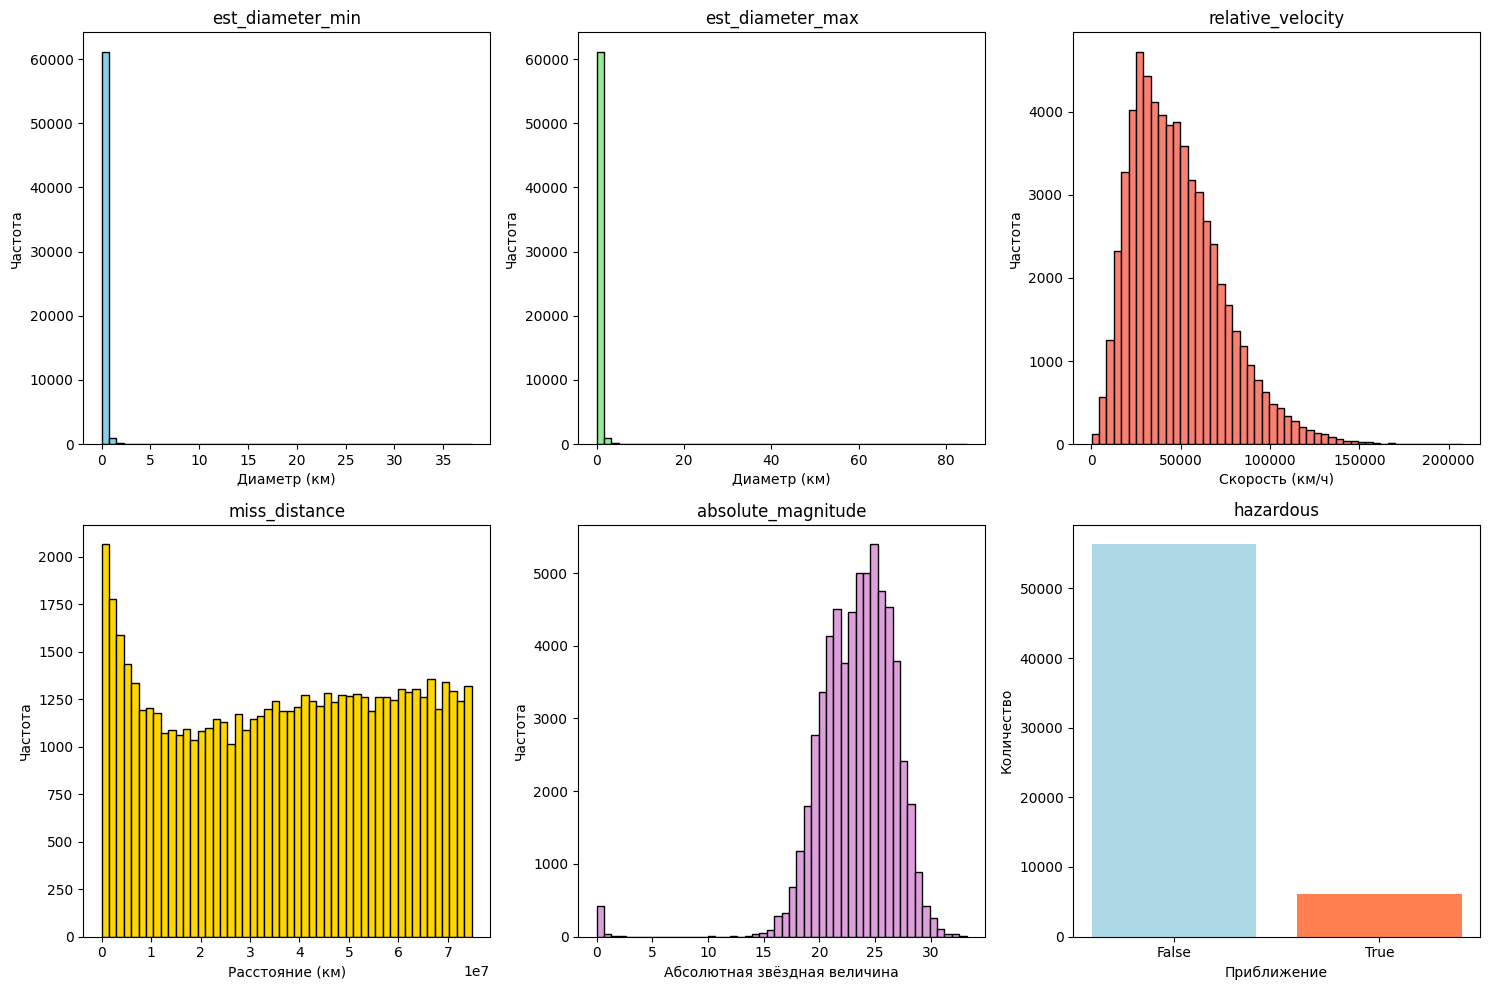

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.hist(file_csv['est_diameter_min'].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.title('est_diameter_min')
plt.xlabel('Диаметр (км)')
plt.ylabel('Частота')

plt.subplot(2, 3, 2)
plt.hist(file_csv['est_diameter_max'].dropna(), bins=50, color='lightgreen', edgecolor='black')
plt.title('est_diameter_max')
plt.xlabel('Диаметр (км)')
plt.ylabel('Частота')

plt.subplot(2, 3, 3)
plt.hist(file_csv['relative_velocity'].dropna(), bins=50, color='salmon', edgecolor='black')
plt.title('relative_velocity')
plt.xlabel('Скорость (км/ч)')
plt.ylabel('Частота')

plt.subplot(2, 3, 4)
plt.hist(file_csv['miss_distance'].dropna(), bins=50, color='gold', edgecolor='black')
plt.title('miss_distance')
plt.xlabel('Расстояние (км)')
plt.ylabel('Частота')

plt.subplot(2, 3, 5)
plt.hist(file_csv['absolute_magnitude'].dropna(), bins=50, color='plum', edgecolor='black')
plt.title('absolute_magnitude')
plt.xlabel('Абсолютная звёздная величина')
plt.ylabel('Частота')

plt.subplot(2, 3, 6)
hazardous_counts = file_csv['hazardous'].value_counts()
plt.bar(['False', 'True'], hazardous_counts.values, color=['lightblue', 'coral'])
plt.title('hazardous')
plt.xlabel('Приближение')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

Ящик с усами:

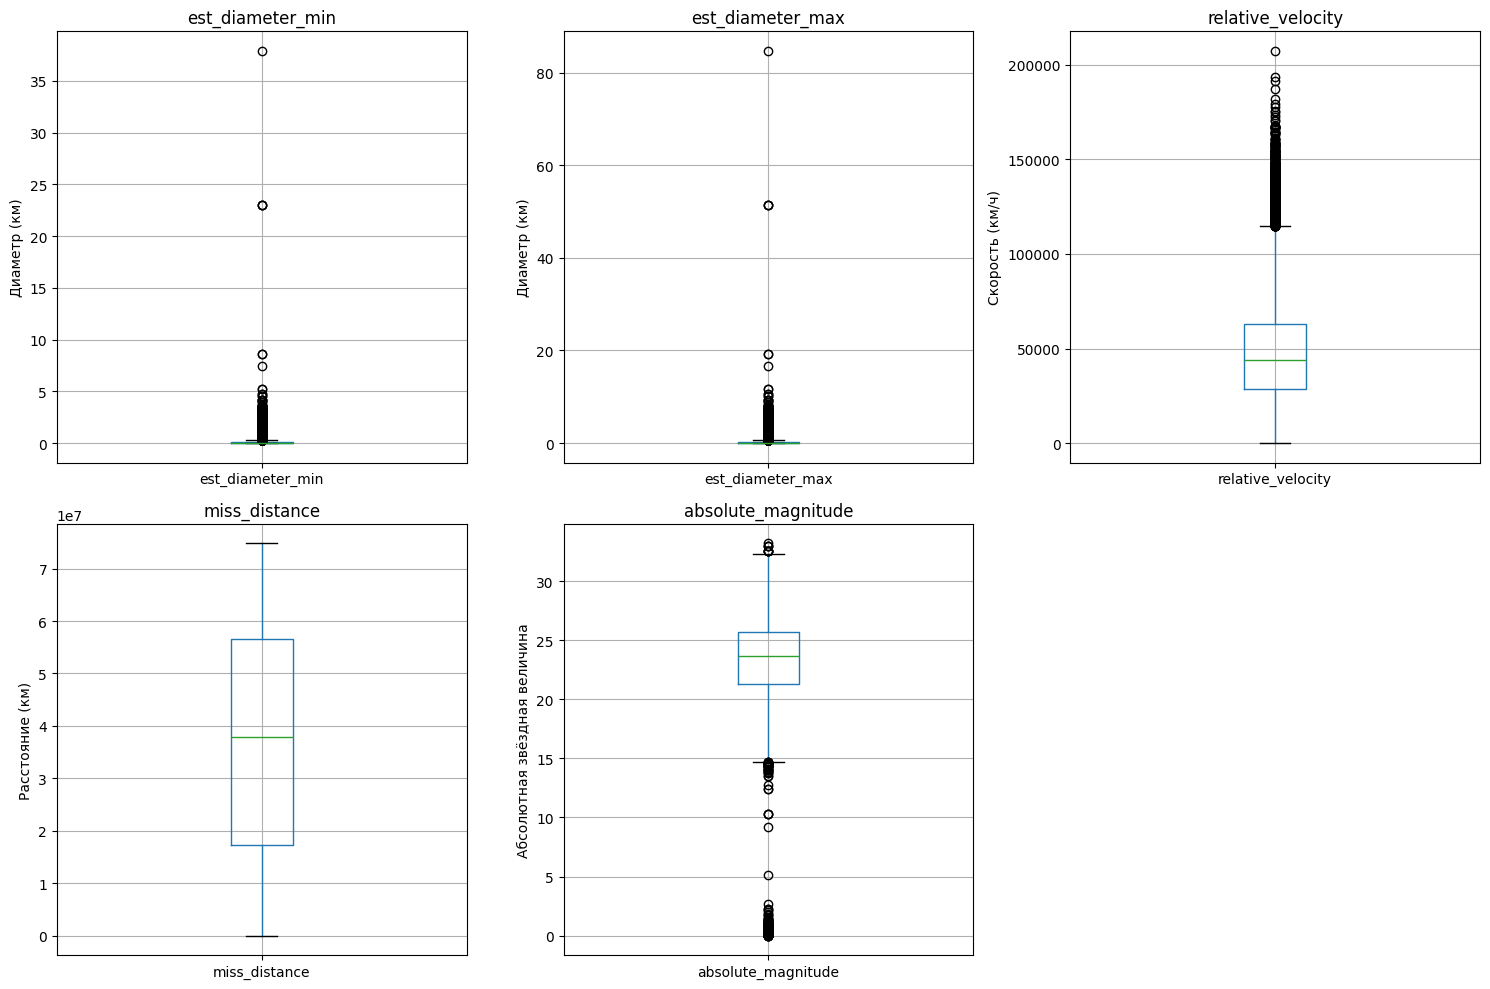

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
file_csv.boxplot(column='est_diameter_min')
plt.title('est_diameter_min')
plt.ylabel('Диаметр (км)')

plt.subplot(2, 3, 2)
file_csv.boxplot(column='est_diameter_max')
plt.title('est_diameter_max')
plt.ylabel('Диаметр (км)')

plt.subplot(2, 3, 3)
file_csv.boxplot(column='relative_velocity')
plt.title('relative_velocity')
plt.ylabel('Скорость (км/ч)')

plt.subplot(2, 3, 4)
file_csv.boxplot(column='miss_distance')
plt.title('miss_distance')
plt.ylabel('Расстояние (км)')

plt.subplot(2, 3, 5)
file_csv.boxplot(column='absolute_magnitude')
plt.title('absolute_magnitude')
plt.ylabel('Абсолютная звёздная величина')

plt.tight_layout()
plt.show()

Тепловая карта :

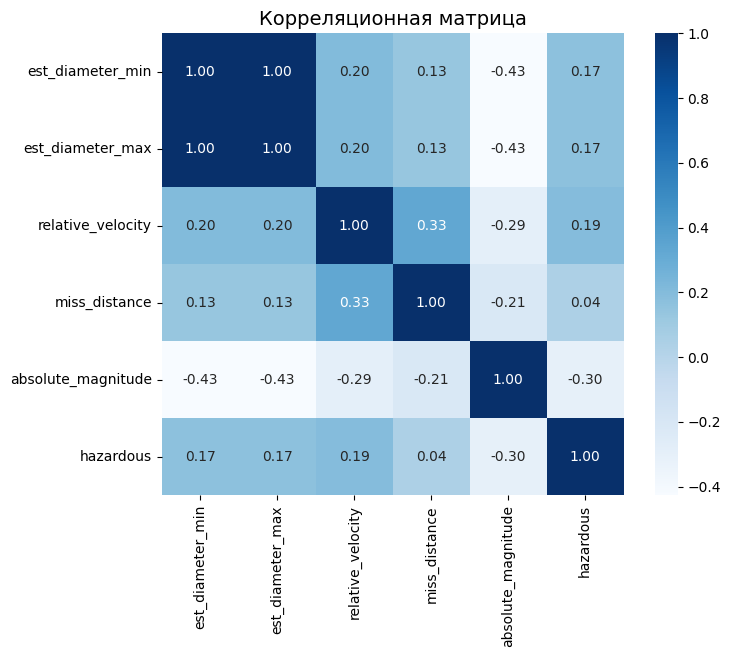

In [ ]:
plt.figure(figsize=(8, 6))
numeric_cols = ['est_diameter_min', 'est_diameter_max', 'relative_velocity',
                'miss_distance', 'absolute_magnitude','hazardous']
sns.heatmap(file_csv[numeric_cols].corr(),
            annot=True,
            cmap='Blues',
            fmt='.2f',
            square=True)
plt.title('Корреляционная матрица', fontsize=14)
plt.show()
file_csv.to_csv(r'csv/neo_task_processed.csv', index=False)

---


**2.4.6 Статистический анализ данных**




Вычислим медиану,моду,среднее,стандартное отклонение, дисперсию:

In [ ]:
def get_basic_statistics(file_csv):
    numeric_cols = file_csv.select_dtypes(include=[np.number]).columns

    basic_stats = pd.DataFrame({
        'count': file_csv[numeric_cols].count(),
        'mean': file_csv[numeric_cols].mean().round(4),
        'median': file_csv[numeric_cols].median().round(4),
        'std': file_csv[numeric_cols].std().round(4),
        'min': file_csv[numeric_cols].min().round(4),
        '25%': file_csv[numeric_cols].quantile(0.25).round(4),
        '50%': file_csv[numeric_cols].quantile(0.50).round(4),
        '75%': file_csv[numeric_cols].quantile(0.75).round(4),
        'max': file_csv[numeric_cols].max().round(4),
        'range': (file_csv[numeric_cols].max() - file_csv[numeric_cols].min()).round(4),
        'IQR': (file_csv[numeric_cols].quantile(0.75) - file_csv[numeric_cols].quantile(0.25)).round(4),
        'cv%': ((file_csv[numeric_cols].std() / file_csv[numeric_cols].mean()) * 100).round(2)
    })

    return basic_stats.T

basic_stats = get_basic_statistics(file_csv)
print(basic_stats)

        est_diameter_min  est_diameter_max  relative_velocity  miss_distance  \
count       62377.000000      62377.000000       62377.000000   6.237700e+04   
mean            0.127400          0.284800       48057.816406   3.711502e+07   
median          0.048400          0.108200       44121.503906   3.788846e+07   
std             0.323100          0.722400       25305.371094   2.235779e+07   
min             0.000600          0.001400         203.346405   6.745533e+03   
25%             0.019300          0.043100       28596.021500   1.727146e+07   
50%             0.048400          0.108200       44121.503900   3.788846e+07   
75%             0.140800          0.314800       63029.203100   5.662726e+07   
max            37.892601         84.730499      207168.671875   7.479865e+07   
range          37.891998         84.729202      206965.328125   7.479190e+07   
IQR             0.121500          0.271700       34433.181600   3.935580e+07   
cv%           253.679993        253.6699

Корреляция коффицентов:

In [ ]:
file_csv['hazardous_numeric'] = file_csv['hazardous'].astype(int)
correlation_with_hazardous = file_csv[numeric_cols + ['hazardous_numeric']].corr()['hazardous_numeric'].sort_values(ascending=False)
print(correlation_with_hazardous)


for col in numeric_cols:
    corr, p_value = stats.pearsonr(file_csv[col].dropna(),
                                    file_csv['absolute_magnitude'].dropna())
    print(f"{col}: corr={corr:.3f}, p-value={p_value:.3e}")

ValueError: cannot convert float NaN to integer

---

**2.5.7 Выявление аномалий и выбросов**

Выведем визуализацию выросов:

In [ ]:
numeric_cols = file_csv.select_dtypes(include=[np.number], exclude=[bool]).columns.tolist()

def get_outlier_bounds(data, column):
    col_data = pd.to_numeric(data[column], errors='coerce')

    if col_data.isna().all():
        return 0, None, None

    q1 = col_data.quantile(0.25)
    q3 = col_data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 3.0 * iqr
    upper = q3 + 3.0 * iqr

    mask = (col_data < lower) | (col_data > upper)
    return int(mask.sum()), lower, upper

print("ВЫБРОСЫ ДО ОБРАБОТКИ:")

plt.figure(figsize=(12, 6))
sns.boxplot(data=file_csv[numeric_cols])
plt.title('Boxplot — до очистки')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n Гистограммы распределения (до очистки):")

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=file_csv, x=col, bins=50, kde=True, color='skyblue')

    count, low, up = get_outlier_bounds(file_csv, col)

    if low is not None and up is not None:
        plt.axvline(low, color='red', linestyle='--', label=f'Нижняя граница: {low:.2f}')
        plt.axvline(up, color='red', linestyle='--', label=f'Верхняя граница: {up:.2f}')

    plt.title(f'Распределение: {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    if count > 0 and low is not None and up is not None:
        outliers = file_csv[(file_csv[col] < low) | (file_csv[col] > up)][col]
        print(f"{col}: {count} выбросов (границы: [{low:.2f}, {up:.2f}])")
        print(f"   Примеры: {outliers.head(3).values}")
    else:
        print(f"{col}: выбросов не обнаружено")

Очистка от выбросов

In [ ]:
bounds = {}
for col in numeric_cols:
    _, low, up = get_outlier_bounds(file_csv, col)
    bounds[col] = (low, up)

print("\n ОБРАБОТКА ВЫБРОСОВ:")
for col, (lower, upper) in bounds.items():
    is_outlier = (file_csv[col] < lower) | (file_csv[col] > upper)
    count = is_outlier.sum()
    if count > 0:
        median_val = file_csv.loc[~is_outlier, col].median()
        file_csv.loc[is_outlier, col] = median_val
        print(f"{col:20s}: заменено {count:4d} выбросов на медиану {median_val:.4f}")

print("\n Boxplot — после очистки:")
plt.figure(figsize=(12, 6))
sns.boxplot(data=file_csv[numeric_cols])
plt.title('Boxplot — после очистки')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n Гистограммы распределения (после очистки):")
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=file_csv, x=col, bins=50, kde=True, color='lightgreen')
    plt.title(f'Распределение: {col} (после очистки)')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

Вывод тепловой карты

In [ ]:
plt.figure(figsize=(8, 6))
numeric_cols = ['est_diameter_min', 'est_diameter_max', 'relative_velocity',
                'miss_distance', 'absolute_magnitude' , 'hazardous']
sns.heatmap(file_csv[numeric_cols].corr(),
            annot=True,
            cmap='Blues',
            fmt='.2f',
            square=True)
plt.title('Корреляционная матрица', fontsize=14)
plt.show()

# **Лабораторная №1**
**ДатаСет 5 из Регрессии**

---

 Подключим датасеты

In [ ]:
path_red = r'csv/winequality-red.csv'

file_csv_red = pd.read_csv(path_red,sep=';')

path_white = r'csv/winequality-white.csv'

file_csv_white = pd.read_csv(path_white,sep=';')

Посмотрим содержимое

In [ ]:
print('Head(20):')
print(file_csv_red.head(20))
print('Info:')
print(file_csv_red.info())
print('Shape:')
print(file_csv_red.shape)

То же и для второго

In [ ]:
print('Head(20):')
print(file_csv_white.head(20))
print('Info:')
print(file_csv_white.info())
print('Shape:')
print(file_csv_white.shape)

Объеденим датасеты и добавим два признака ( красный / белый )

In [ ]:
file_csv_red['wine_type'] = 'red'
file_csv_white['wine_type'] = 'white'

df = pd.concat([file_csv_red, file_csv_white], ignore_index=True)
output_path = 'csv/winequality_combined.csv'
df.to_csv(output_path, index=False, encoding='utf-8',sep=';')

In [ ]:
path_combined = r'csv/winequality_combined.csv'

file_csv_combined = pd.read_csv(path_combined,sep=';')

print('Head(20):')
print(file_csv_combined.head(20))
print('Info:')
print(file_csv_combined.info())
print('Shape:')
print(file_csv_combined.shape)

2.1.1 Цель:
Поиск закономерностей и аномалий

2.1.3 Очистка данных

Проверим пропуски

In [ ]:
file_csv_combined.isna().sum()

In [ ]:
print('Info:')
print(file_csv_combined.info())

О, можно преобразовать даные

In [ ]:
num_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
            'density', 'pH', 'sulphates', 'alcohol']

file_csv_combined[num_cols] = file_csv_combined[num_cols].astype('float32')

file_csv_combined['quality'] = file_csv_combined['quality'].astype('float32')
file_csv_combined['wine_type'] = file_csv_combined['wine_type'].map({'red': 0, 'white': 1})

In [ ]:
print('Info:')
print(file_csv_combined.info())

**2.2.4 Анализ структуры данных**

In [ ]:
file_csv_combined.describe()

## `fixed acidity` (фиксированная кислотность, г/дм³)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 6 497 | Нет пропущенных значений |
| mean | 7.22 г/дм³ | Средняя фиксированная кислотность 7.22 г/дм³ |
| std | 1.30 г/дм³ | Стандартное отклонение 1.30 г/дм³ |
| min | 3.80 г/дм³ | Минимальная кислотность 3.8 г/дм³ |
| 25% | 6.40 г/дм³ | 25% вин имеют кислотность ≤ 6.4 г/дм³ |
| 50% | 7.00 г/дм³ | 50% вин имеют кислотность ≤ 7.0 г/дм³ |
| 75% | 7.70 г/дм³ | 75% вин имеют кислотность ≤ 7.7 г/дм³ |
| max | 15.90 г/дм³ | Максимальная кислотность 15.9 г/дм³ |

## `volatile acidity` (летучая кислотность, г/дм³)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 6 497 | Нет пропущенных значений |
| mean | 0.34 г/дм³ | Средняя летучая кислотность 0.34 г/дм³ |
| std | 0.16 г/дм³ | Стандартное отклонение 0.16 г/дм³ |
| min | 0.08 г/дм³ | Минимальное значение 0.08 г/дм³ |
| 25% | 0.23 г/дм³ | 25% вин имеют ≤ 0.23 г/дм³ |
| 50% | 0.29 г/дм³ | 50% вин имеют ≤ 0.29 г/дм³ |
| 75% | 0.40 г/дм³ | 75% вин имеют ≤ 0.40 г/дм³ |
| max | 1.58 г/дм³ | Максимальное значение 1.58 г/дм³ |

## `citric acid` (лимонная кислота, г/дм³)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 6 497 | Нет пропущенных значений |
| mean | 0.32 г/дм³ | Средняя концентрация 0.32 г/дм³ |
| std | 0.15 г/дм³ | Стандартное отклонение 0.15 г/дм³ |
| min | 0.00 г/дм³ | В некоторых винах отсутствует |
| 25% | 0.25 г/дм³ | 25% вин имеют ≤ 0.25 г/дм³ |
| 50% | 0.31 г/дм³ | 50% вин имеют ≤ 0.31 г/дм³ |
| 75% | 0.39 г/дм³ | 75% вин имеют ≤ 0.39 г/дм³ |
| max | 1.66 г/дм³ | Максимальное значение 1.66 г/дм³ |

## `residual sugar` (остаточный сахар, г/дм³)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 6 497 | Нет пропущенных значений |
| mean | 5.44 г/дм³ | Среднее содержание сахара 5.44 г/дм³ |
| std | 4.76 г/дм³ | Высокая вариативность (сухие → сладкие вина) |
| min | 0.60 г/дм³ | Очень сухие вина |
| 25% | 1.80 г/дм³ | 25% вин имеют ≤ 1.8 г/дм³ |
| 50% | 3.00 г/дм³ | 50% вин имеют ≤ 3.0 г/дм³ |
| 75% | 8.10 г/дм³ | 75% вин имеют ≤ 8.1 г/дм³ |
| max | 65.80 г/дм³ | Максимальное значение 65.8 г/дм³ |

## `chlorides` (хлориды, г/дм³)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 6 497 | Нет пропущенных значений |
| mean | 0.056 г/дм³ | Средняя концентрация хлоридов |
| std | 0.035 г/дм³ | Стандартное отклонение 0.035 г/дм³ |
| min | 0.009 г/дм³ | Минимальное содержание |
| 25% | 0.038 г/дм³ | 25% вин имеют ≤ 0.038 г/дм³ |
| 50% | 0.047 г/дм³ | 50% вин имеют ≤ 0.047 г/дм³ |
| 75% | 0.065 г/дм³ | 75% вин имеют ≤ 0.065 г/дм³ |
| max | 0.611 г/дм³ | Максимальное значение 0.611 г/дм³ |

## `free sulfur dioxide` (свободный SO₂, мг/дм³)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 6 497 | Нет пропущенных значений |
| mean | 30.53 мг/дм³ | Средняя концентрация свободного SO₂ |
| std | 17.75 мг/дм³ | Стандартное отклонение 17.75 мг/дм³ |
| min | 1.00 мг/дм³ | Минимальное значение |
| 25% | 17.00 мг/дм³ | 25% вин имеют ≤ 17 мг/дм³ |
| 50% | 29.00 мг/дм³ | 50% вин имеют ≤ 29 мг/дм³ |
| 75% | 41.00 мг/дм³ | 75% вин имеют ≤ 41 мг/дм³ |
| max | 289.00 мг/дм³ | Максимальное значение 289 мг/дм³ |

## `total sulfur dioxide` (общий SO₂, мг/дм³)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 6 497 | Нет пропущенных значений |
| mean | 115.74 мг/дм³ | Средняя общая концентрация SO₂ |
| std | 56.52 мг/дм³ | Стандартное отклонение 56.52 мг/дм³ |
| min | 6.00 мг/дм³ | Минимальное значение |
| 25% | 77.00 мг/дм³ | 25% вин имеют ≤ 77 мг/дм³ |
| 50% | 118.00 мг/дм³ | 50% вин имеют ≤ 118 мг/дм³ |
| 75% | 156.00 мг/дм³ | 75% вин имеют ≤ 156 мг/дм³ |
| max | 440.00 мг/дм³ | Максимальное значение 440 мг/дм³ |

## `density` (плотность, г/см³)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 6 497 | Нет пропущенных значений |
| mean | 0.9947 г/см³ | Средняя плотность близка к воде |
| std | 0.0030 г/см³ | Низкая вариативность |
| min | 0.9871 г/см³ | Минимальная плотность |
| 25% | 0.9923 г/см³ | 25% вин имеют плотность ≤ 0.9923 г/см³ |
| 50% | 0.9949 г/см³ | 50% вин имеют плотность ≤ 0.9949 г/см³ |
| 75% | 0.9970 г/см³ | 75% вин имеют плотность ≤ 0.9970 г/см³ |
| max | 1.0390 г/см³ | Максимальная плотность 1.039 г/см³ |

## `pH` (кислотность по шкале pH)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 6 497 | Нет пропущенных значений |
| mean | 3.22 | Средняя кислотность в шкале pH |
| std | 0.16 | Стандартное отклонение 0.16 |
| min | 2.72 | Минимальное значение (очень кислые вина) |
| 25% | 3.11 | 25% вин имеют pH ≤ 3.11 |
| 50% | 3.21 | 50% вин имеют pH ≤ 3.21 |
| 75% | 3.32 | 75% вин имеют pH ≤ 3.32 |
| max | 4.01 | Максимальное значение 4.01 |

## `sulphates` (сульфаты, г/дм³)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 6 497 | Нет пропущенных значений |
| mean | 0.53 г/дм³ | Средняя концентрация сульфатов |
| std | 0.15 г/дм³ | Стандартное отклонение 0.15 г/дм³ |
| min | 0.22 г/дм³ | Минимальное значение |
| 25% | 0.43 г/дм³ | 25% вин имеют ≤ 0.43 г/дм³ |
| 50% | 0.51 г/дм³ | 50% вин имеют ≤ 0.51 г/дм³ |
| 75% | 0.60 г/дм³ | 75% вин имеют ≤ 0.60 г/дм³ |
| max | 2.00 г/дм³ | Максимальное значение 2.00 г/дм³ |

## `alcohol` (алкоголь, % об.)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 6 497 | Нет пропущенных значений |
| mean | 10.49 % | Средняя крепость 10.49% об. |
| std | 1.19 % | Стандартное отклонение 1.19% |
| min | 8.00 % | Минимальная крепость |
| 25% | 9.50 % | 25% вин имеют крепость ≤ 9.5% |
| 50% | 10.30 % | 50% вин имеют крепость ≤ 10.3% |
| 75% | 11.30 % | 75% вин имеют крепость ≤ 11.3% |
| max | 14.90 % | Максимальная крепость 14.9% об. |

## `quality` (целевая переменная, баллы 3–9)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 6 497 | Нет пропущенных значений |
| mean | 5.82 | Средняя оценка 5.82 из 9 |
| std | 0.87 | Стандартное отклонение 0.87 |
| min | 3.00 | Наименьшая оценка в датасете |
| 25% | 5.00 | 25% вин оценены ≤ 5 баллов |
| 50% | 6.00 | 50% вин оценены ≤ 6 баллов |
| 75% | 6.00 | 75% вин оценены ≤ 6 баллов |
| max | 9.00 | Наивысшая оценка в датасете |

## `wine_type` (тип вина, закодированный: 0=red, 1=white)

| Показатель | Значение | Интерпретация |
|-----------|----------|---------------|
| count | 6 497 | Нет пропущенных значений |
| mean | 0.75 | Доля белого вина ~75% |
| std | 0.43 | Стандартное отклонение для бинарного признака |
| min | 0.00 | Присутствует красное вино |
| 25% | 1.00 | 25-й процентиль = белое вино |
| 50% | 1.00 | Медиана = белое вино |
| 75% | 1.00 | 75-й процентиль = белое вино |
| max | 1.00 | Максимум = белое вино |

2.4.6 Визуализация данных

Гистограмма

In [ ]:
plt.figure(figsize=(18, 12))

plt.subplot(3, 4, 1)
plt.hist(df['fixed acidity'].dropna(), bins=40, color='skyblue', edgecolor='black')
plt.title('fixed acidity')
plt.xlabel('г/дм³')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 2)
plt.hist(df['volatile acidity'].dropna(), bins=40, color='lightgreen', edgecolor='black')
plt.title('volatile acidity')
plt.xlabel('г/дм³')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 3)
plt.hist(df['citric acid'].dropna(), bins=40, color='salmon', edgecolor='black')
plt.title('citric acid')
plt.xlabel('г/дм³')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 4)
plt.hist(df['residual sugar'].dropna(), bins=40, color='gold', edgecolor='black')
plt.title('residual sugar')
plt.xlabel('г/дм³')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 5)
plt.hist(df['chlorides'].dropna(), bins=40, color='plum', edgecolor='black')
plt.title('chlorides')
plt.xlabel('г/дм³')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 6)
plt.hist(df['free sulfur dioxide'].dropna(), bins=40, color='lightcoral', edgecolor='black')
plt.title('free sulfur dioxide')
plt.xlabel('мг/дм³')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 7)
plt.hist(df['total sulfur dioxide'].dropna(), bins=40, color='lightblue', edgecolor='black')
plt.title('total sulfur dioxide')
plt.xlabel('мг/дм³')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 8)
plt.hist(df['density'].dropna(), bins=40, color='lightyellow', edgecolor='black')
plt.title('density')
plt.xlabel('г/см³')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 9)
plt.hist(df['pH'].dropna(), bins=40, color='lightpink', edgecolor='black')
plt.title('pH')
plt.xlabel('pH')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 10)
plt.hist(df['sulphates'].dropna(), bins=40, color='lightseagreen', edgecolor='black')
plt.title('sulphates')
plt.xlabel('г/дм³')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 11)
plt.hist(df['alcohol'].dropna(), bins=40, color='orange', edgecolor='black')
plt.title('alcohol')
plt.xlabel('% об.')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 12)
quality_counts = df['quality'].value_counts().sort_index()
plt.bar(quality_counts.index, quality_counts.values, color='coral', edgecolor='black')
plt.title('quality (target)')
plt.xlabel('Оценка')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.3)

plt.suptitle('Распределение признаков в датасете вина', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wine_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

Ящик с усами

In [ ]:
plt.figure(figsize=(18, 12))

plt.subplot(3, 4, 1)
df.boxplot(column='fixed acidity', vert=True, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.title('fixed acidity')
plt.ylabel('г/дм³')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 2)
df.boxplot(column='volatile acidity', vert=True, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.title('volatile acidity')
plt.ylabel('г/дм³')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 3)
df.boxplot(column='citric acid', vert=True, patch_artist=True, boxprops=dict(facecolor='salmon'))
plt.title('citric acid')
plt.ylabel('г/дм³')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 4)
df.boxplot(column='residual sugar', vert=True, patch_artist=True, boxprops=dict(facecolor='gold'))
plt.title('residual sugar')
plt.ylabel('г/дм³')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 5)
df.boxplot(column='chlorides', vert=True, patch_artist=True, boxprops=dict(facecolor='plum'))
plt.title('chlorides')
plt.ylabel('г/дм³')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 6)
df.boxplot(column='free sulfur dioxide', vert=True, patch_artist=True, boxprops=dict(facecolor='lightcoral'))
plt.title('free sulfur dioxide')
plt.ylabel('мг/дм³')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 7)
df.boxplot(column='total sulfur dioxide', vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('total sulfur dioxide')
plt.ylabel('мг/дм³')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 8)
df.boxplot(column='density', vert=True, patch_artist=True, boxprops=dict(facecolor='lightyellow'))
plt.title('density')
plt.ylabel('г/см³')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 9)
df.boxplot(column='pH', vert=True, patch_artist=True, boxprops=dict(facecolor='lightpink'))
plt.title('pH')
plt.ylabel('pH')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 10)
df.boxplot(column='sulphates', vert=True, patch_artist=True, boxprops=dict(facecolor='lightseagreen'))
plt.title('sulphates')
plt.ylabel('г/дм³')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 11)
df.boxplot(column='alcohol', vert=True, patch_artist=True, boxprops=dict(facecolor='orange'))
plt.title('alcohol')
plt.ylabel('% об.')
plt.grid(axis='y', alpha=0.3)

plt.subplot(3, 4, 12)
df.boxplot(column='quality', vert=True, patch_artist=True, boxprops=dict(facecolor='coral'))
plt.title('quality (target)')
plt.ylabel('Оценка')
plt.grid(axis='y', alpha=0.3)

plt.suptitle('Boxplot: выбросы и распределение признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wine_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

Тепловая карта

In [ ]:
df_plot = df.copy()
if df_plot['wine_type'].dtype == 'object':
    df_plot['wine_type_enc'] = df_plot['wine_type'].map({'red': 0, 'white': 1})
else:
    df_plot['wine_type_enc'] = df_plot['wine_type']

numeric_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
                'density', 'pH', 'sulphates', 'alcohol', 'quality', 'wine_type_enc']

plt.figure(figsize=(12, 10))
corr_matrix = df_plot[numeric_cols].corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции'})

plt.title('Корреляционная матрица признаков (включая quality)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('wine_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Корреляция признаков с качеством вина (quality):")
corr_with_quality = corr_matrix['quality'].drop('quality').sort_values(ascending=False)
for feat, val in corr_with_quality.items():
    sign = '+' if val >= 0 else ''
    print(f"  {feat:25s}: {sign}{val:.3f}")

**2.4.6 Статистический анализ данных**


Вычислим медиану,моду,среднее,стандартное отклонение, дисперсию:

In [ ]:
def get_basic_statistics(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    basic_stats = pd.DataFrame({
        'count': df[numeric_cols].count(),
        'mean': df[numeric_cols].mean().round(4),
        'median': df[numeric_cols].median().round(4),
        'var': df[numeric_cols].var().round(4),
        'std': df[numeric_cols].std().round(4),
        'min': df[numeric_cols].min().round(4),
        '25%': df[numeric_cols].quantile(0.25).round(4),
        '50%': df[numeric_cols].quantile(0.50).round(4),
        '75%': df[numeric_cols].quantile(0.75).round(4),
        'max': df[numeric_cols].max().round(4),
        'range': (df[numeric_cols].max() - df[numeric_cols].min()).round(4),
        'IQR': (df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)).round(4),
        'cv%': ((df[numeric_cols].std() / df[numeric_cols].mean()) * 100).round(2)
    })

    return basic_stats.T

basic_stats = get_basic_statistics(df)
print(basic_stats)

Обработка аномалий и выбросов

In [ ]:
def handle_outliers(df, columns):
    df_clean = df.copy()
    outlier_stats = []

    print(f"{'Признак':<25} | {'До очистки':<10} | {'Границы':<25} | {'После очистки':<10}")
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        count_before = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

        df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

        count_after = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

        print(f"{col:<25} | {count_before:<10} | [{lower_bound:.2f}; {upper_bound:.2f}] | {count_after:<10}")

    return df_clean
features_to_clean = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                     'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
                     'density', 'pH', 'sulphates', 'alcohol']

df_clean = handle_outliers(df, features_to_clean)

plt.figure(figsize=(18, 12))

plt.subplot(3, 4, 1)
df_clean.boxplot(column='fixed acidity', vert=True, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.title('fixed acidity (Cleaned)')
plt.ylabel('г/дм³')

plt.subplot(3, 4, 2)
df_clean.boxplot(column='volatile acidity', vert=True, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.title('volatile acidity (Cleaned)')
plt.ylabel('г/дм³')

plt.subplot(3, 4, 3)
df_clean.boxplot(column='citric acid', vert=True, patch_artist=True, boxprops=dict(facecolor='salmon'))
plt.title('citric acid (Cleaned)')
plt.ylabel('г/дм³')

plt.subplot(3, 4, 4)
df_clean.boxplot(column='residual sugar', vert=True, patch_artist=True, boxprops=dict(facecolor='gold'))
plt.title('residual sugar (Cleaned)')
plt.ylabel('г/дм³')

plt.subplot(3, 4, 5)
df_clean.boxplot(column='chlorides', vert=True, patch_artist=True, boxprops=dict(facecolor='plum'))
plt.title('chlorides (Cleaned)')
plt.ylabel('г/дм³')

plt.subplot(3, 4, 6)
df_clean.boxplot(column='free sulfur dioxide', vert=True, patch_artist=True, boxprops=dict(facecolor='lightcoral'))
plt.title('free sulfur dioxide (Cleaned)')
plt.ylabel('мг/дм³')

plt.subplot(3, 4, 7)
df_clean.boxplot(column='total sulfur dioxide', vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('total sulfur dioxide (Cleaned)')
plt.ylabel('мг/дм³')

plt.subplot(3, 4, 8)
df_clean.boxplot(column='density', vert=True, patch_artist=True, boxprops=dict(facecolor='lightyellow'))
plt.title('density (Cleaned)')
plt.ylabel('г/см³')

plt.subplot(3, 4, 9)
df_clean.boxplot(column='pH', vert=True, patch_artist=True, boxprops=dict(facecolor='lightpink'))
plt.title('pH (Cleaned)')
plt.ylabel('pH')

plt.subplot(3, 4, 10)
df_clean.boxplot(column='sulphates', vert=True, patch_artist=True, boxprops=dict(facecolor='lightseagreen'))
plt.title('sulphates (Cleaned)')
plt.ylabel('г/дм³')

plt.subplot(3, 4, 11)
df_clean.boxplot(column='alcohol', vert=True, patch_artist=True, boxprops=dict(facecolor='orange'))
plt.title('alcohol (Cleaned)')
plt.ylabel('% об.')

plt.subplot(3, 4, 12)
df_clean.boxplot(column='quality', vert=True, patch_artist=True, boxprops=dict(facecolor='coral'))
plt.title('quality (Original)')
plt.ylabel('Оценка')

plt.suptitle('Boxplot ПОСЛЕ обработки выбросов (Clipping)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wine_boxplots_cleaned.png', dpi=150, bbox_inches='tight')
plt.show()

тепловая карта

In [ ]:
df_plot = df.copy()
if df_plot['wine_type'].dtype == 'object':
    df_plot['wine_type_enc'] = df_plot['wine_type'].map({'red': 0, 'white': 1})
else:
    df_plot['wine_type_enc'] = df_plot['wine_type']

numeric_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
                'density', 'pH', 'sulphates', 'alcohol', 'quality', 'wine_type_enc']

plt.figure(figsize=(12, 10))
corr_matrix = df_plot[numeric_cols].corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции'})

plt.title('Корреляционная матрица признаков (включая quality)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n Корреляция признаков с качеством вина (quality):")
corr_with_quality = corr_matrix['quality'].drop('quality').sort_values(ascending=False)
for feat, val in corr_with_quality.items():
    sign = '+' if val >= 0 else ''
    print(f"  {feat:25s}: {sign}{val:.3f}")